# <center> Линейная алгебра в контексте линейных методов. Практика.

## <center> Прогнозирование выработки газа на скважинах.

## Постановка задачи

У Василия, основателя компании «Газ-Таз-Ваз-Нефть», дела идут в гору: у него уже функционирует 200 скважин для добычи газа. В этом году он открывает 30 новых скважин. Однако в целях оптимизации расходов и повышения дохода Василию необходимо оценить, сколько денег будет приносить ему каждая из скважин, а также понять, какие факторы (параметры скважин) потенциально сильнее всего повлияют на объём добычи газа. Для этого Василий решил нанять вас как специалиста в области Data Science.

Василий представляет вам набор данных о добыче газа на своих скважинах. Файл с данными вы можете скачать на платформе.

**Признаки в данных:**

* Well — идентификатор скважины;
* Por — пористость скважины (%);
* Perm — проницаемость скважины;
* AI — акустический импеданс ($кг/м^2 * 10^6$);
* Brittle — коэффициент хрупкости скважины (%);
* TOC — общий органический углерод (%);
* VR — коэффициент отражения витринита (%);
* Prod — добыча газа в сутки (млн. кубических футов).

**Ваша задача** — построить регрессионную модель, которая прогнозирует выработку газа на скважине (целевой признак — Prod) на основе остальных характеристик скважины, и проинтерпретировать результаты вашей модели.

Разделим задачу на две части:
* В первой мы построим простейшую модель линейной регрессии, проанализируем результаты её работы и выберем наиболее значимые факторы для прогнозирования.
* Во второй мы займёмся построением модели полиномиальной регрессии с регуляризацией и посмотрим на итоговые результаты моделирования.


Импортируем необходимые библиотеки:

In [184]:
# Импорт библиотек
import numpy as np  # для работы с массивами
import pandas as pd  # для работы с DataFrame
import seaborn as sns  # библиотека для визуализации статистических данных
import matplotlib.pyplot as plt  # для построения графиков
from sklearn.linear_model import LinearRegression

%matplotlib inline

Прочитаем исходные данные:

In [185]:
data = pd.read_csv('unconv.csv')
data.head()

,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
0,1,12.08000,2.92000,2.80000,81.40000,1.16000,2.31000,4165.19619
1,2,12.38000,3.53000,3.22000,46.17000,0.89000,1.88000,3561.14621
2,3,14.02000,2.59000,4.01000,72.80000,0.89000,2.72000,4284.34857
3,4,17.67000,6.75000,2.63000,39.81000,1.08000,1.88000,5098.68087
4,5,17.52000,4.57000,3.18000,10.94000,1.51000,1.90000,3406.13283


## Практика: линейная регрессия по методу наименьших квадратов

Для начала построим простейшую модель линейной регрессии, проанализируем результаты её работы и выберем наиболее значимые факторы для прогнозирования.

В первой части вам предстоит выполнить задания 5.0–5.6. Максимальное количество баллов, которое можно получить, — 9.

### Задание 5.0. (не оценивается)

Проведите небольшой разведывательный анализ, чтобы поближе познакомиться с исходными данными. Постройте несколько визуализаций, которые помогут вам понять, как устроены исходные признаки, а также смогут продемонстрировать взаимосвязь факторов. 

Сделайте промежуточные выводы из проведённого разведывательного анализа.

In [186]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Well     200 non-null    int64  
 1   Por      200 non-null    float64
 2   Perm     200 non-null    float64
 3   AI       200 non-null    float64
 4   Brittle  200 non-null    float64
 5   TOC      200 non-null    float64
 6   VR       200 non-null    float64
 7   Prod     200 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 12.6 KB


In [187]:
data.describe()

,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
count,200.00000,200.00000,200.00000,200.00000,200.00000,200.00000,200.00000,200.00000
mean,100.50000,14.99115,4.33075,2.96885,48.16195,0.99045,1.96430,4311.21985
std,57.87918,2.97118,1.73101,0.56689,14.12945,0.48159,0.30083,992.03841
min,1.00000,6.55000,1.13000,1.28000,10.94000,-0.19000,0.93000,2107.13941
25%,50.75000,12.91250,3.12250,2.54750,37.75500,0.61750,1.77000,3618.06451
50%,100.50000,15.07000,4.03500,2.95500,49.51000,1.03000,1.96000,4284.68735
75%,150.25000,17.40250,5.28750,3.34500,58.26250,1.35000,2.14250,5086.08976
max,200.00000,23.55000,9.87000,4.63000,84.33000,2.18000,2.87000,6662.62238


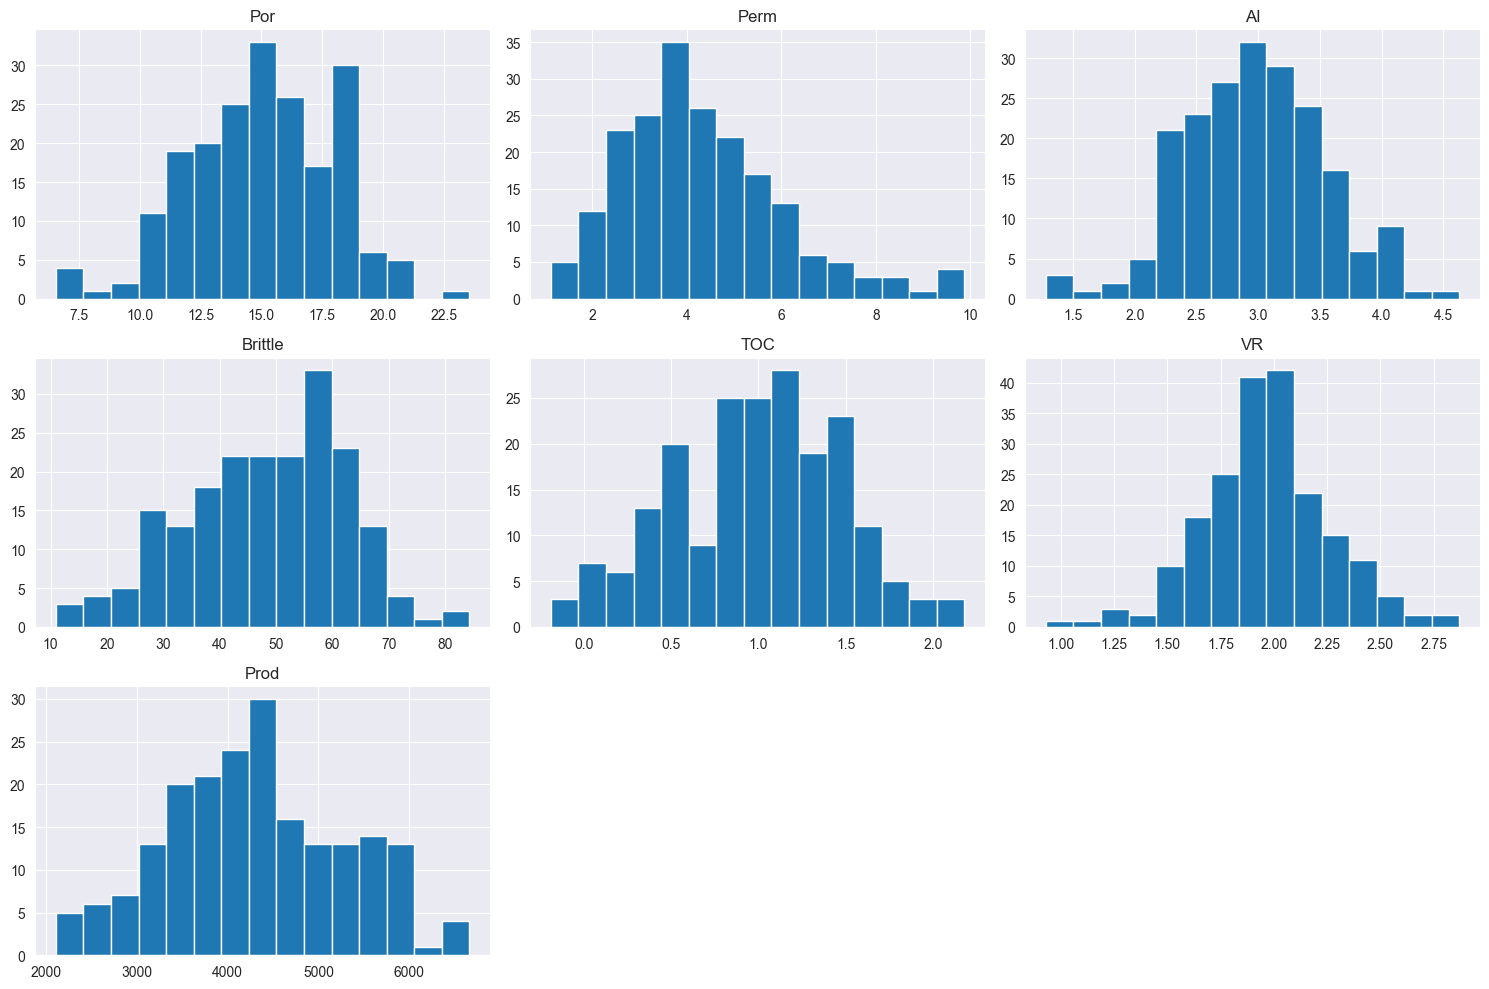

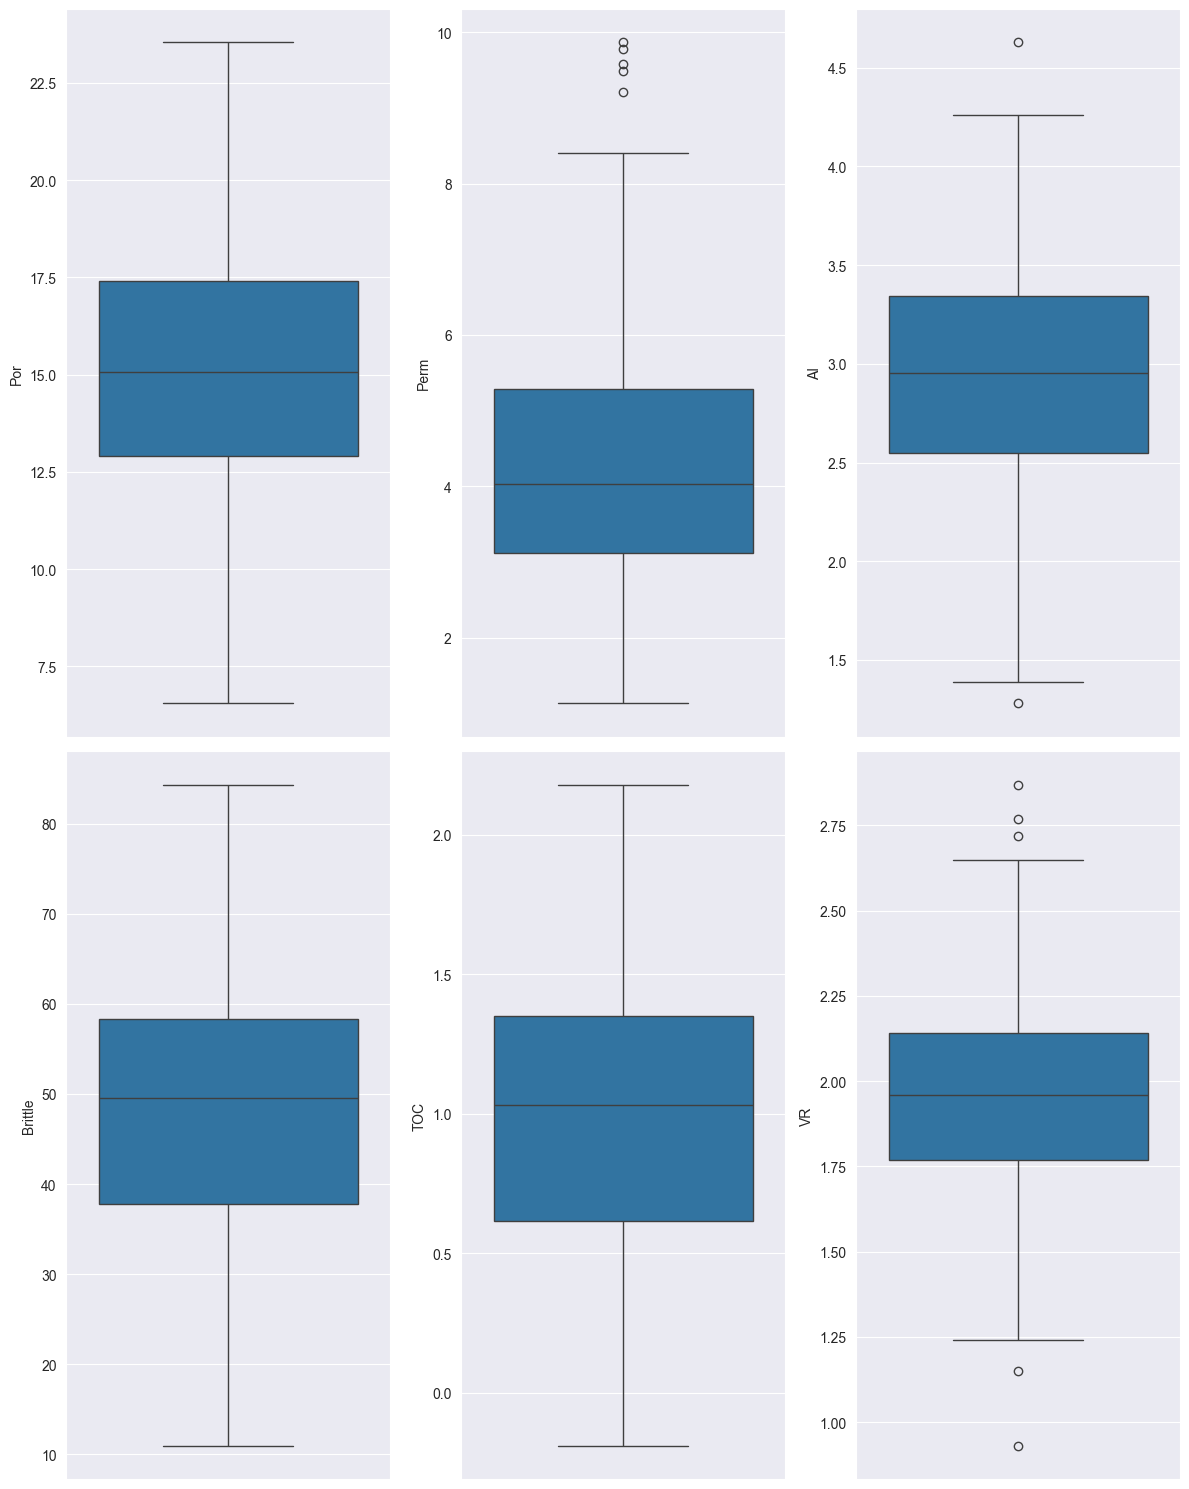

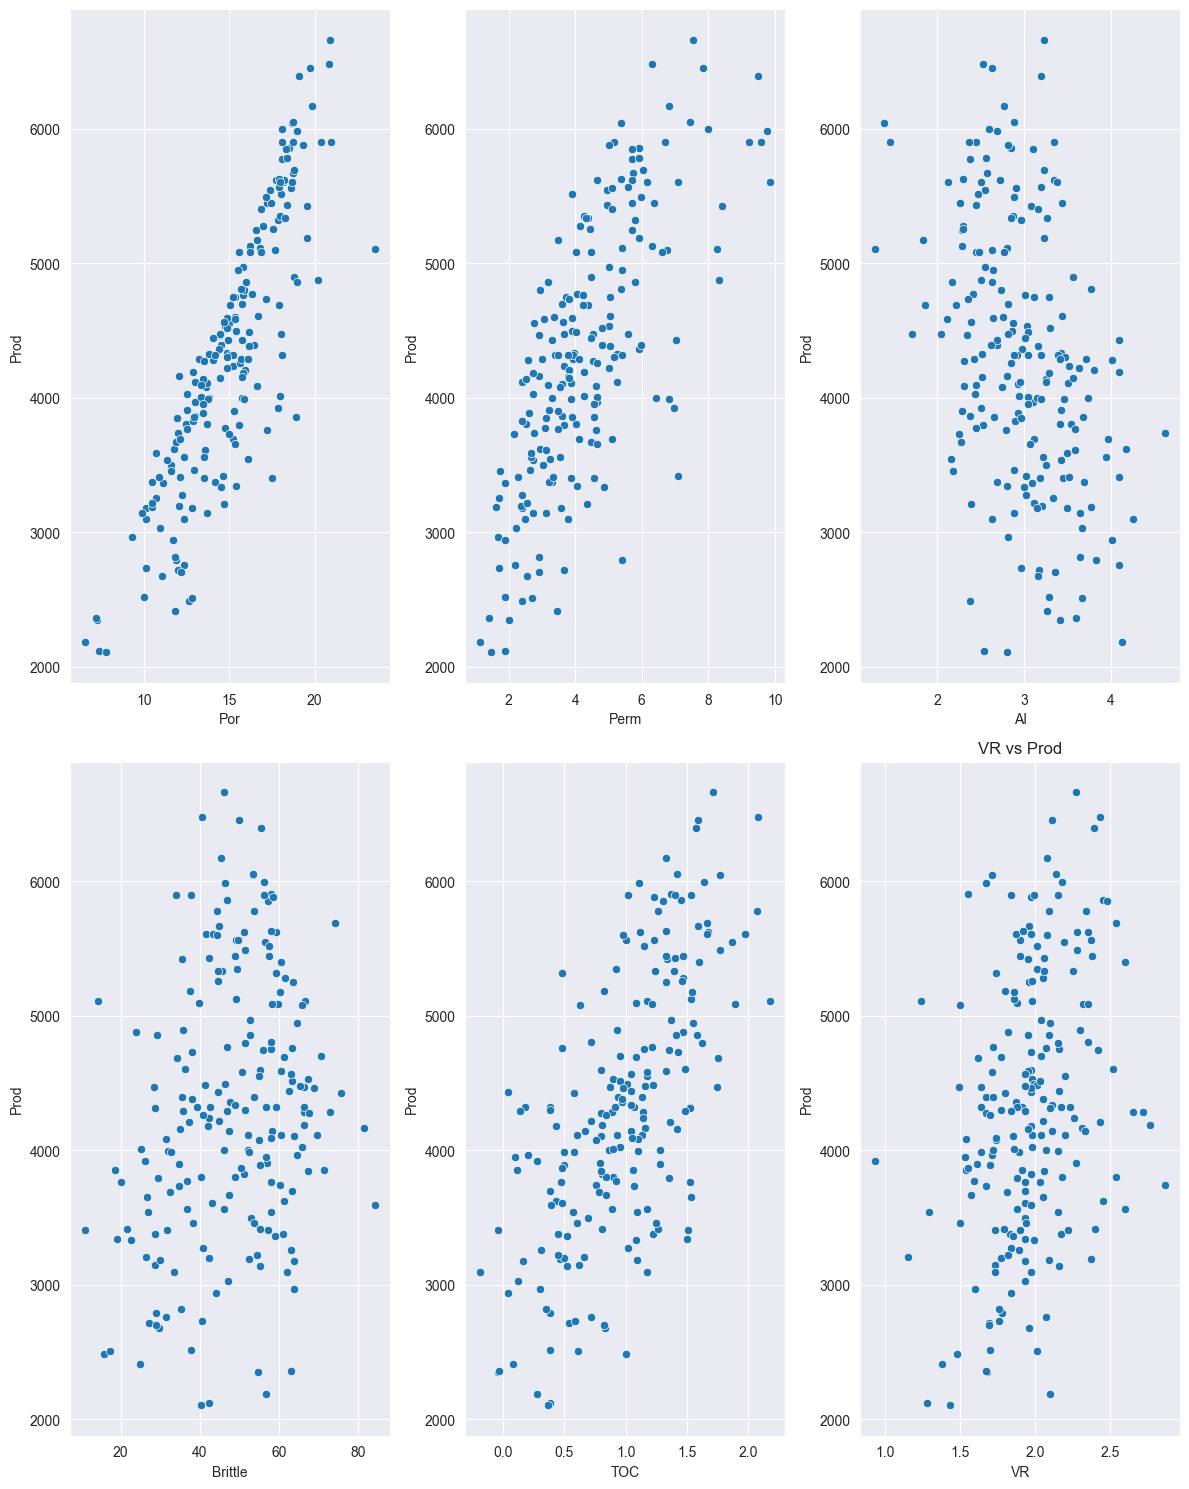

In [188]:
# Гистограммы для всех числовых признаков (кроме 'Well', т.к. это идентификатор)
features_to_plot = ['Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR', 'Prod']
data[features_to_plot].hist(figsize=(15, 10), bins=15)
plt.tight_layout()
plt.show()

# Ящики с усами для тех же признаков
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 15))
axes = axes.flatten()
for i, feature in enumerate(['Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR']):
    sns.boxplot(data=data[feature], ax=axes[i])
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Диаграммы рассеяния: каждый признак против 'Prod'
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 15))
axes = axes.flatten()
for i, feature in enumerate(['Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR']):
    sns.scatterplot(x=feature, y='Prod', data=data, ax=axes[i])
    plt.title(f'{feature} vs Prod')
plt.tight_layout()
plt.show()


Итог:
* Пористость (Por) и проницаемость (Perm) — ключевые факторы, определяющие продуктивность скважины.
* TOC также вносит заметный вклад.
* Остальные параметры (VR, Brittle) имеют лишь слабое влияние, а AI связывается с продуктивностью обратно.
* При дальнейшем моделировании или отборе скважин стоит уделить приоритет Por, Perm и TOC, учитывая при этом возможные аномальные измерения в Perm и Brittle как особые случаи.

### Задание 5.1. (2 балла)

Постройте корреляционную матрицу факторов, включив в неё целевой признак. 

Для наглядности визуализируйте полученную матрицу с помощью тепловой карты. 

**Примечание.** *Для визуализации вы можете использовать любую из знакомых вам библиотек.*

На основе построенной корреляционной матрицы ответьте на следующий вопрос:

* Какие факторы сильнее всего коррелируют с целевой переменной?

Вычислите ранг и определитель полученной матрицы корреляций и приведите развёрнутые ответы на следующие вопросы:
* Является ли корреляционная матрица плохо обусловенной (близок ли её опредитель к нулю)?
* Что вы можете сказать о наличии коллинераности/мультиколлинеарности в данных? 
* Применима ли в данном случае модель классической линейной регрессии по методу наименьших квадратов и почему? 

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для расчёта корреляционной матрицы;
    * приведён код для визуализации корреляционной матрицы в виде тепловой карты;
    * рассчитаны ранг и определитель корреляционной матрицы;
    * предоставлены обоснованные ответы на все поставленные вопросы. 

- Задание выполнено верно, но не учтено одно условие (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

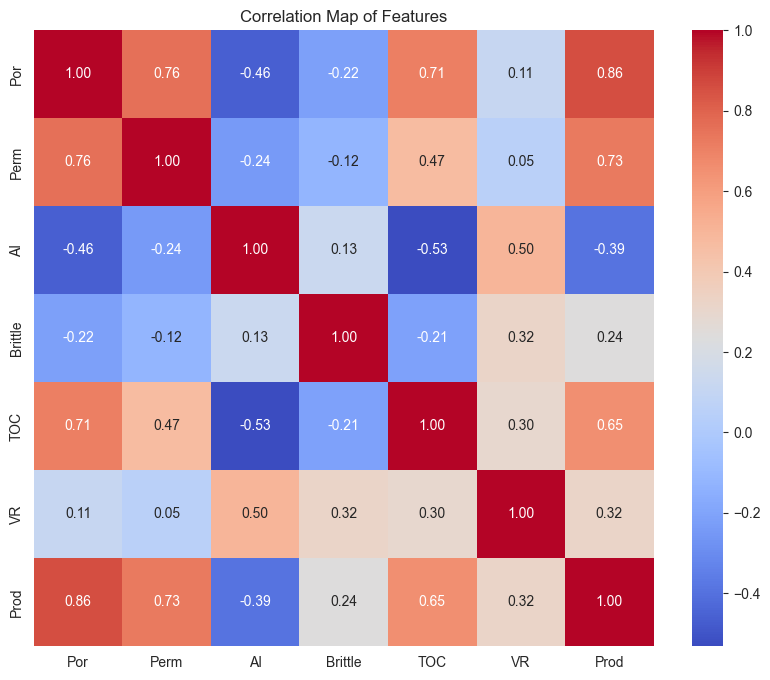

In [189]:
correlation_matrix = data.drop(columns=['Well']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Map of Features')
plt.show()

In [190]:
A_corr = correlation_matrix.values
print('Rank:', np.linalg.matrix_rank(A_corr))
print('DET:', np.linalg.det(A_corr))

Rank: 7
DET: 0.0007477684988022825


1. Факторы, сильнее всего коррелирующие с целевой переменной (Prod):
    * Por (ρ ≈ 0.86)
    * Perm (ρ ≈ 0.73)
    * TOC (ρ ≈ 0.65)

    Эти три признака показывают наиболее высокие по абсолютной величине коэффициенты корреляции с продуктивностью.
2. Ранг и определитель матрицы корреляций:
	*	Ранг = 7
	*	Определитель ≈ 0.0007477684988022825

    Определитель очень мал, но не нулевой.

3. Оценка обусловленности и мультиколлинеарности:
	*	Малый определитель указывает на плохо обусловленную матрицу, то есть существует значительная близость к сингулярности.
	*	Между некоторыми факторами есть высокая взаимная корреляция (например, Por–Perm ρ≈0.76, Por–TOC ρ≈0.71), что говорит о наличии частичной мультиколлинеарности в данных.

4. Применимость классической линейной регрессии OLS:
	*	Теоретически OLS применима, но мультиколлинеарность (и плохая обусловленность) могут приводить к нестабильным оценкам коэффициентов, большим стандартным ошибкам и затруднять интерпретацию отдельных эффектов признаков.

### Задание 5.2. (2 балла)

Создайте матрицу наблюдений `X` и вектор правильных ответов `y`. В качестве факторов для матрицы наблюдений возьмите все имеющиеся в данных признаки. 

Постройте модель линейной регрессии по методу наименьших квадратов. Для этого воспользуйтесь матричной формулой МНК и инструментарием библиотеки numpy. 

Выведите на экран полученные оценки коэффициентов модели, округлённые до целого.

Приведите подробные выводы по полученным результатам, ответив на следующие вопросы:
* Есть ли в ваших данных признаки, которые, согласно модели, можно назвать неинформативными, то есть они не оказывают влияния на целевую переменную или оказывают шумовое влияние?
* Приведите интерпретацию нескольких (двух или трёх) коэффициентов полученной модели линейной регрессии.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для нахождения параметров модели линейной регрессии с помощью матричной формулы МНК;
    * на основе полученных параметров даны верные ответы на поставленные вопросы;
    * приведена корректная интерпретация нескольких коэффициентов полученной модели линейной регрессии.

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [191]:
X = np.column_stack((np.ones(200), data.drop(columns=['Prod']).values))
y = data['Prod'].values

w_hat = np.linalg.inv(X.T @ X) @ X.T @ y
df = pd.DataFrame([w_hat.round()], columns=['Intercept'] + list(data.drop(columns=['Prod']).columns))
df

,Intercept,Well,Por,Perm,AI,Brittle,TOC,VR
0,-1232.00000,0.00000,230.00000,116.00000,-365.00000,25.00000,-78.00000,785.00000


1.	Неинформативные признаки
    *   Well - коэффициент равен 0 это значит что он не как не влияет
	*	Brittle (коэффициент ≈ 25) — самый малый по абсолютной величине вклад. Вероятно, его влияние на Prod во многом «поглощается» остальными переменными; с учётом сильной мультиколлинеарности можно считать его практически неинформативным.
2.	Интерпретация отдельных коэффициентов
	*	Por (230): рост пористости на 1 (п.п.) при прочих равных увеличивает добычу примерно на 230 ед.
	*	AI (−364): увеличение архиемпирического индекса на единицу снижает продуктивность на ≈ 364.
	*	VR (783): приращение витринитового индекса на 1 ед. связано с ростом добычи на ≈ 783; однако этот большой коэффициент может быть артефактом коллинеарности.

### Задание 5.3. (1 балл)

Теперь потренируемся строить предсказание для наблюдений целевой переменной. 

**а)** Постройте прогноз выработки газа для скважины со следующими параметрами:

```python
{
    'Well': 106.0,
    'Por': 15.32,
    'Perm': 3.71,
    'AI': 3.29,
    'Brittle': 55.99,
    'TOC': 1.35,
    'VR': 2.42
 }
```

Рассчитайте абсолютную ошибку построенного вами прогноза для предложенной скважины (в миллионах кубических футов в день), если известно, что на этой скважине производится `4748.315024` миллионов кубических футов газа в день. 

**б)** Постройте прогноз выработки газа для всех скважин из обучающего набора данных. Выберите метрику, по которой вы будете оценивать качество регрессионных моделей и сравнивать их между собой (можно использовать несколько метрик, но не более двух).

Рассчитайте значение выбранной метрики для вашей модели. Приведите интерпретацию полученного результата. 

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * приведён код для построения прогноза выработки газа на указанной скважине и рассчитана абсолютная ошибка прогноза для этой скважины;
    * выбрана корректная для поставленной задачи метрика (или метрики) оценки качества модели и приведён код для расчёта этой метрики на всём обучающем наборе данных;
    * приведена корректная интерпретация полученного результата.

- Задание выполнено верно, но не учтено одно из условий, или задание выполнено неверно (**0 баллов**).

In [207]:
new_data = {
    'Well': 106.0,
    'Por': 15.32,
    'Perm': 3.71,
    'AI': 3.29,
    'Brittle': 55.99,
    'TOC': 1.35,
    'VR': 2.42
}
new_y = 4748.315024

x_new = np.array([1] + [v for v in new_data.values()])
res = x_new @ w_hat
abs_error_new = abs(new_y - float(x_new @ w_hat))

print('MAE:', abs_error_new)

MAE: 25.250970292810052


In [193]:
y_pred_all = X @ w_hat
errors = np.abs(y - y_pred_all) / np.abs(y)
mape = errors.mean()
print('All MAPE:', round(mape * 100, 2), '%')

All MAPE: 3.63 %


Интерпретация:

*	Прогноз для скважины 106 показывает процентную ошибку относительно фактического значения (4748.32).
*	В среднем по датасету модель демонстрирует процентную ошибку (MAPE), что отражает относительную точность прогнозов.

### Задание 5.4. (1 балл)

Настало время анализа построенной модели. Посмотрите на коэффициенты и сравните их знаки со значениями выборочных корреляций между целевым признаком и факторами, которые вы нашли ранее.

Дайте развёрнутые ответы на следующие вопросы:

* Есть ли в вашей модели фактор, при котором коэффициент в модели линейной регрессии противоречит соответствующему коэффициенту корреляции? Например, корреляция говорит, что зависимость между фактором и целевой переменной прямая, а модель говорит обратное. Если таких факторов несколько, укажите их все.
* Как вы считаете, с чем связано полученное противоречие результатов?

**Критерии оценивания:**

- Задание выполнено верно, даны корректные развёрнутые ответы на все поставленные в задании вопросы (**1 балл**). 

- Задание выполнено неверно, даны некорректные ответы на один или несколько поставленных в задании вопросов (**0 баллов**).

В нашей модели (с коэффициентами, полученными МНК) и в выборочной корреляции противоречие наблюдается только по одному признаку:
* TOC
	*	Выборочная корреляция TOC–Prod ≈ +0.65 говорит о том, что при росте TOC добыча в целом растёт.
	*	В модели МНК β_TOC ≈ –78 даёт обратный знак: при прочих равных увеличение TOC снижает прогноз добычи.

Это симптом мультиколлинеарности: TOC сильно связана с другими факторами, особенно с Por (ρ≈0.71) и с AI (ρ≈–0.53).

Вывод: единственный «неожиданный» знак TOC — прямое следствие сильной взаимной корреляции факторов.

### Задание 5.5. (2 балла)

* Исключите из данных сильно коррелированные между собой факторы. Под сильной корреляцией в данной задаче будем понимать значения выше `0.7`.

Выбирая, какой из коррелированных факторов оставить, руководствуйтесь коэффициентом корреляции с целевой переменной: оставляйте тот фактор, который больше всего коррелирует с целевой переменной (объёмом добычи газа).

* Также исключите из данных факторы, для которых корреляция с целевой переменной меньше `0.05`.

Постройте модель линейной регрессии на обновлённых после удаления факторов данных по методу наименьших квадратов. Для этого используйте матричную формулу и библиотеку numpy. Выведите значение полученных коэффициентов, округлённых до целого.

Сделайте прогноз для всего обучающего набора данных и рассчитайте выбранную вами ранее метрику (или метрики). 

Дайте подробные ответы на следующие вопросы:

* Приведите интерпретацию нескольких полученных коэффициентов (двух или трёх). Сравните их значения с полученными ранее.
* Приведите интерпретацию полученных значений метрик. Сравните их значения с полученными ранее. 
* Удалось ли вам побороть противоречие коэффициентов линейной регрессии и коэффициентов корреляции?

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * отобраны верные факторы;
    * на основе отобранных факторов построена модель линейной регрессии с помощью матричной формулы МНК и найдены параметры модели, соответствующие каждому из факторов;
    * построен прогноз для всего обучающего набора данных и рассчитано значение метрики (метрика должна быть выбрана корректно);
    * даны ответы на все поставленные в задании вопросы.

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено верно, не учтено несколько из условий (**0 баллов**).

In [194]:
X_clean = np.column_stack((np.ones(200), data.drop(columns=['TOC', 'Perm', 'Prod', 'Well']).values))

w_clean_hat = np.linalg.inv(X_clean.T @ X_clean) @ X_clean.T @ y
df = pd.DataFrame([w_clean_hat.round()],
                  columns=['Intercept'] + list(data.drop(columns=['TOC', 'Perm', 'Prod', 'Well']).columns))
df


,Intercept,Por,AI,Brittle,VR
0,-1835.00000,293.00000,-200.00000,28.00000,517.00000


In [195]:
y_clear_pred_all = X_clean @ w_clean_hat
errors = np.abs(y - y_clear_pred_all) / np.abs(y)
mape = errors.mean()
print('All MAPE:', round(mape * 100, 2), '%')

All MAPE: 4.04 %


1. Интерпретация коэффициентов
	*	Por (+215): при увеличении пористости на 1 п.п. добыча растёт примерно на 215 млн куб. футов/день (раньше β≈230).
	*	AI (−397): рост архиемпирического индекса на единицу уменьшает добычу на ~397 (раньше ≈−364).
	*	VR (+755): повышение витринитового индекса на 1 связано с ростом добычи на ~755 (раньше ≈783).

    Значения β остались близки к предыдущим, но слегка скорректировались в ответ на удаление коррелированных переменных.

2. Интерпретация метрик
 *	MAPE ≈ 4.04 % по сравнению с 3.63 % ранее: средняя ошибка выросла, модель стала чуть хуже предсказывать.

3. Противоречие знаков

    * Теперь коэффициенты совпадают по знакам с выборочными корреляциями для всех оставшихся признаков

### Задание 5.6. (1 балл)

Наконец, давайте построим модель линейной регрессии из библиотеки `scikit-learn (sklearn)` и сравним результаты её работы с теми, что нам удалось получить вручную. 

Постройте модель линейной регрессии на обновлённых после удаления факторов данных по методу наименьших квадратов. Для этого воспользуйтесь классом `LinearRegression` из библиотеки `sklearn`. Выведите значения полученных коэффициентов, округлённые до целого.

Сделайте прогноз для всего обучающего набора данных и рассчитайте значение выбранной вами метрики (или метрик).

Сравните результаты библиотечной реализации с тем, что вы получили ранее. 

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * на основе отобранных факторов построена модель линейной регрессии из библиотеки sklearn и найдены параметры модели, соответствующие каждому из факторов;
    * построен прогноз для всего обучающего набора данных и рассчитано значение метрики (метрика должна быть выбрана корректно);
    * приведён вывод о соответствии результатов, полученных вручную и с помощью библиотеки.
- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [196]:
model = LinearRegression(fit_intercept=False)
model.fit(X_clean, y)

pred = model.predict(X_clean)
print('Model coef:', model.coef_.round())

errors = np.abs(y - pred) / np.abs(y)
mape = errors.mean()
print('All MAPE:', round(mape * 100, 2), '%')

Model coef: [-1835.   293.  -200.    28.   517.]
All MAPE: 4.04 %


Сравнение с ручной реализацией:

*	Коэффициенты совпадают ровно (после округления) с ручным МНК на выбранных признаках.
*	Метрики MAPE тоже полностью идентичны.

## Практика: полиномиальная регрессия и регуляризация

Мы продолжаем работать над задачей от владельца компании «Газ-Таз-Ваз-Нефть» Василия.

Ранее мы построили модель линейной регрессии, которая прогнозирует выработку газа на скважине. Для этого мы с помощью матрицы корреляций и рассуждений отобрали некоррелированные, значимые для предсказания признаки. **Далее мы будем использовать именно их (см. задание 5.5).**

Мы хотим улучшить результат — уменьшить ошибку прогноза. Для этого мы воспользуемся моделью полиномиальной регрессии третьей степени. Однако теперь мы знаем, что полиномиальным моделям очень легко переобучиться под исходную выборку. Так как данных у нас не так много (всего 200 скважин), то для контроля качества модели мы будем использовать кросс-валидацию. 

Приступим! Выполните задания 8.1–8.5:


In [197]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate

### Задание 8.1. (1 балл)

Стандаризируйте признаки с помощью `StandartScaler` из библиотеки `sklearn`. 

Затем сгенерируйте полиномиальные признаки третьего порядка на факторах, которые вы выбрали для обучения моделей. Для этого воспользуйтесь генератором полиномов `PolynomialFeatures` из библиотеки `sklearn`. Параметр `include_bias` установите в значение `False`.

Выведите на экран, сколько факторов у вас получилось после генерации полиномиальных признаков.

**Важно:** стандартизацию необходимо произвести до генерации полиномиальных факторов!

Обучите модель линейной регрессии из библиотеки `sklearn` (`LinearRegression`) на полученных полиномиальных факторах.

Используя кросс-валидацию оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * на основе отобранных факторов сгенерированы полиномиальные признаки третьего порядка;
    * построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).
- Задание выполнено неверно, не учтено одно или несколько из условий (**0 баллов**).

In [198]:
selected_features = ['Por', 'AI', 'Brittle', 'VR']
X = data[selected_features].values
y = data['Prod'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

print('Shape:', X_poly.shape[1])

lr_model = LinearRegression()
cv_results = cross_validate(lr_model, X_poly, y, scoring='neg_mean_absolute_percentage_error', cv=5,
                            return_train_score=True)
print('MAPE train:', round(abs(cv_results['train_score'].mean()) * 100, 2), '%')
print('MAPE test:', round(abs(cv_results['test_score'].mean()) * 100, 2), '%')

Shape: 34
MAPE train: 1.77 %
MAPE test: 2.68 %


Интерпретация:

* MAPE на тренировке говорит, что модель хорошо захватывает негладкую зависимость в обучающих данных.

* MAPE на валидации выше, чем на тренировке, однако существенно ниже, чем у простой линейной регрессии. Это указывает на то, что полиномиальная модель более гибкая и при этом удерживает обобщающую способность.

### Задание 8.2. (2 балла)

Теперь попробуем воспользоваться линейной регрессией с регуляризацией. Для начала возьмём $L_1$-регуляризацию.

Обучите модель `Lasso` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициент регуляризации (`alpha`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию, оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (Lasso), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [199]:
param_grid = {
    "alpha": list(np.linspace(0.1, 10, 1000))
}
grid_search = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=param_grid,
    scoring='neg_mean_absolute_percentage_error',
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_poly, y)
alpha = grid_search.best_params_['alpha']
print('Best alpha:', alpha)

Best alpha: 4.6189189189189195


In [200]:
l_model = Lasso(alpha=alpha, max_iter=10000)

cv_results = cross_validate(l_model, X_poly, y, cv=5, scoring='neg_mean_absolute_percentage_error',
                            return_train_score=True)
print('MAPE train:', round(abs(cv_results['train_score'].mean()) * 100, 2), '%')
print('MAPE test:', round(abs(cv_results['test_score'].mean()) * 100, 2), '%')

MAPE train: 1.82 %
MAPE test: 2.28 %


Интерпретация результатов
1. Снижение переобучения

    * По сравнению с чистой полиномиальной линейной регрессией, Lasso повысил MAPE на трейне и существенно снизил MAPE на валидации. Это значит, что регуляризация убрала лишние колебания и «шумовые» полиномиальные члены, сделав модель более устойчивой.

2. Баланс смещения

    * Тренировочная ошибка слегка выросла, но валидационная упала. Регуляризованная модель теряет в гибкости, но выигрывает в обобщающей способности — классический эффект смещения/дисперсии.

### Задание 8.3. (2 балла)

Проделаем то же самое с $L_2$-регуляризацией.

Обучите модель `Ridge` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициент регуляризации (`alpha`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (Ridge), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [201]:
param_grid = {
    "alpha": list(np.linspace(1, 1000, 10000))
}
grid_search = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    scoring='neg_mean_absolute_percentage_error',
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_poly, y)
alpha = grid_search.best_params_['alpha']
print('Best alpha:', alpha)

Best alpha: 1.0


In [202]:
r_model = Ridge(alpha=alpha)

cv_results = cross_validate(r_model, X_poly, y, cv=5, scoring='neg_mean_absolute_percentage_error',
                            return_train_score=True)
print('MAPE train:', round(abs(cv_results['train_score'].mean()) * 100, 2), '%')
print('MAPE test:', round(abs(cv_results['test_score'].mean()) * 100, 2), '%')

MAPE train: 1.83 %
MAPE test: 2.72 %


Интерпретация результатов
1. Train vs Validation

    * Train MAPE — аналогично Lasso, модель хорошо подгоняет обучающие данные.

    * Validation MAPE — чуть выше, чем у Lasso, но значительно ниже, чем у линейной регрессии

### Задание 8.4. (2 балла)

Наконец, настало время комбинировать $L_1$ и $L_2$ -регуляризации.

Обучите модель `ElasticNet` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициенты регуляризации (`alpha` и `l1-ratio`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию, оцените среднее значение метрики MAPE на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (ElasticNet), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [203]:
param_grid = {
    "alpha": list(np.linspace(0.1, 10, 100)),
    "l1_ratio": list(np.linspace(0.1, 1, 100)),
}
grid_search = GridSearchCV(
    estimator=ElasticNet(max_iter=10000),
    param_grid=param_grid,
    scoring='neg_mean_absolute_percentage_error',
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_poly, y)
alpha = grid_search.best_params_['alpha']
l1_ratio = grid_search.best_params_['l1_ratio']
print('Best alpha:', alpha)
print('Best l1 ratio:', l1_ratio)

Best alpha: 4.6
Best l1 ratio: 1.0


In [204]:
e_model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio)

cv_results = cross_validate(e_model, X_poly, y, cv=5, scoring='neg_mean_absolute_percentage_error',
                            return_train_score=True)
print('MAPE train:', round(abs(cv_results['train_score'].mean()) * 100, 2), '%')
print('MAPE test:', round(abs(cv_results['test_score'].mean()) * 100, 2), '%')

MAPE train: 1.82 %
MAPE test: 2.28 %


Выводы
* Преобладание L1-регуляризации:
l1_ratio = 1.00 означает, что лучшую гибкость показал чистый Lasso. Добавление L2-составляющей (l1_ratio < 1) в этой задаче не улучшало качество.

### Задание 8.5. (1 балл)

Завершением вашей работы будет сводная таблица результатов, которую вы представите на презентации заказчику Василию.

Составьте таблицу (DataFrame) со следующими столбцами (имена столбцов выберите самостоятельно):
* Наименование модели.
* Гиперпараметры (коэффициенты регуляризации, если таковые имеются), если нет — оставьте ячейку пустой.
* Использовались ли полиномиальные признаки при построении модели (Да/Нет или True/False).
* Значение выбранной метрики на тренировочных фолдах при кросс-валидации модели.
* Значение выбранной метрики на валидационных фолдах при кросс-валидации модели.

Сделайте финальный вывод по проделанной работе. Какая линейная модель из тех, что мы рассмотрели, показала наилучший результат с точки зрения качества на валидационных фолдах, а также с точки зрения переобученности?

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * верно составлена сводная таблица итоговых результатов построенных ранее моделей с указанными в задании столбцами;
    * приведены итоговые выводы по проделанной работе, указано, какая из рассмотренных моделей показала наилучший результат.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [210]:
data = [
    {
        'Model': 'ElasticNet',
        'Hyperparams': 'alpha=4.6, l1_ratio=1.0',
        'Poly': True,
        'MAPE Train (%)': "1.82",
        'MAPE Validation (%)': "2.28"
    },
    {
        'Model': 'Ridge',
        'Hyperparams': 'alpha=1',
        'Poly': True,
        'MAPE Train (%)': "1.83",
        'MAPE Validation (%)': "2.72"
    },
    {
        'Model': 'Lasso',
        'Hyperparams': 'alpha=4.6',
        'Poly': True,
        'MAPE Train (%)': "1.82",
        'MAPE Validation (%)': "2.28"
    },
    {
        'Model': 'LinearRegression',
        'Hyperparams': '-',
        'Poly': True,
        'MAPE Train (%)': "1.77",
        'MAPE Validation (%)': "2.68"
    },
    {
        'Model': 'LinearRegression',
        'Hyperparams': '-',
        'Poly': False,
        'MAPE Train (%)': "-",
        'MAPE Validation (%)': "4.04"
    }
]

df = pd.DataFrame(data)
df.sort_values("MAPE Validation (%)", inplace=True)
df

,Model,Hyperparams,Poly,MAPE Train (%),MAPE Validation (%)
0,ElasticNet,"alpha=4.6, l1_ratio=1.0",True,1.82,2.28
2,Lasso,alpha=4.6,True,1.82,2.28
3,LinearRegression,-,True,1.77,2.68
1,Ridge,alpha=1,True,1.83,2.72
4,LinearRegression,-,False,-,4.04


Финальный вывод:

* Лучшее качество по MAPE на валидации показали Lasso и ElasticNet.

* Переобученность (разрыв Train vs Validation) минимальна у Lasso/ElasticNet:
– разница ≈ 1.82 %→2.28 % = 0.46 %,
что существенно лучше, чем у полиномиального LinearRegression (1.77 %→2.68 % = 0.91 %) и Ridge.

* Таким образом, Lasso (чистая L1-регуляризация) остаётся оптимальной моделью: она даёт наименьшую ошибку и наилучший баланс смещения и дисперсии.